# Z4 PRS $\mu\sim\mathcal{O}(1)$ test scan — analysis

Analysis of `scan_z4_prs_mu1`: 4 cards testing the **IR-band fix** (2026-06-10).  
Root cause of all previous PRS failures: PRS freezes the comoving tachyonic band at $k<\mu$;
old runs ($\mu=0.01/0.1$) had $k_{\rm IR}=2\pi/L\ge\mu$ → zero or marginal unstable modes → field
never broke (verified: rms decays $\propto 1/a$ exactly). Fix: $\mu\sim\mathcal{O}(1)$ so
$2\pi/L\ll\mu\lesssim\sqrt{2}/(4\delta x)$ (many tachyonic modes, walls $\sim$7 cells wide forever).

| Card | $\mu$ | $N$ | $\beta_4$ | PRS | Notes |
|---|---|---|---|---|---|
| `mu0p5_std`       | 0.5 | 256 | 0.1 | off | control — std EOM, walls de-resolve at late $a$ |
| `mu0p5_prs`       | 0.5 | 256 | 0.1 | on  | **key test** — PRS from $t_0$, no staging |
| `mu0p5_b40p9_prs` | 0.5 | 256 | 0.9 | on  | $\beta_4$ variation |
| `mu1_N512_prs`    | 1.0 | 512 | 0.1 | on  | prod-quality, $\sim$2100 tachyonic modes |

All cards: $L=100$, $H_0=\mu$ ($\Rightarrow a=1+\eta$), $\lambda_1-2\lambda_2=\mu^2$ ($v=1$).  
Frozen wall width $\sqrt{2}/\mu$: 7.2 cells ($\mu=0.5$, $N=256$, $dx=0.39$) / 7.2 cells ($\mu=1$, $N=512$, $dx=0.20$).  
Tachyonic modes: $\sim$260 ($\mu=0.5$) / $\sim$2100 ($\mu=1$).  

**Primary success criterion:** $\langle|\Phi|^2\rangle=(\langle h^2\rangle+\langle a^2\rangle)/2$
rises to $\approx0.5$ after formation and **stays**.  
Melt $\Leftrightarrow$ drops below $0.25$ $\Leftrightarrow$ $E_{v,1}$ sign flip.  
x-axis: scale factor $a=1+\eta$ (same for all runs since $H_0=\mu$).  

Missing/partial runs are silently skipped — re-run as results arrive.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

USETEX = True
rc('text', usetex=USETEX)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

`average_energies.txt` columns (11): `eta, Ek_1, Ek_2, Eg_1, Eg_2, Ev_1, Ev_2, Ev_3, E_tot, Scal_type_1, Scal_type_2`.  
`average_scalar_{i}.txt` columns (7): `eta, mean, mean_prime, phi2, phi_prime2, rms_phi, rms_phi_prime`.  
`average_scale_factor.txt` columns (4): `eta, a, a_prime, H`.  
Energies are normalized by $\mu^2/4$ (the potential barrier height at $\phi=0$ above vacuum,
$V_0=\mu^4/[4(\lambda_1-2\lambda_2)]=\mu^2/4$ at $v=1$) so all $\mu$ are comparable.  
$E_{v,1}/(\mu^2/4)$: $+1$ at origin, $-1$ at vacuum — universal.

In [3]:
BASE = '/mt/user-batch/dpasari/scan_z4_prs_mu1/'

CONFIGS = [
    dict(name='mu0p5_std',       dir='results_DWZ4_mu0p5_std',
         mu=0.5, beta4=0.1, prs=False, N=256, lSide=100.0,
         label=r'$\mu=0.5$ std $\beta_4=0.1$ (control)'),
    dict(name='mu0p5_prs',       dir='results_DWZ4_mu0p5_prs',
         mu=0.5, beta4=0.1, prs=True,  N=256, lSide=100.0,
         label=r'$\mu=0.5$ PRS $\beta_4=0.1$'),
    dict(name='mu0p5_b40p9_prs', dir='results_DWZ4_mu0p5_b40p9_prs',
         mu=0.5, beta4=0.9, prs=True,  N=256, lSide=100.0,
         label=r'$\mu=0.5$ PRS $\beta_4=0.9$'),
    dict(name='mu1_N512_prs',    dir='results_DWZ4_mu1_N512_prs',
         mu=1.0, beta4=0.1, prs=True,  N=512, lSide=100.0,
         label=r'$\mu=1.0$ PRS $\beta_4=0.1$ ($N=512$)'),
]

_PALETTE = {
    'mu0p5_std':       ('0.30',    'solid',   2.4),
    'mu0p5_prs':       ('#2ca02c', (0,(5,2)), 2.4),
    'mu0p5_b40p9_prs': ('#d62728', (0,(5,2)), 2.4),
    'mu1_N512_prs':    ('#1f77b4', (0,(8,2)), 2.4),
}
for c in CONFIGS:
    c['color'], c['ls'], c['lw'] = _PALETTE[c['name']]

def config_handles(items):
    return [Line2D([0],[0], color=d['color'], lw=d['lw'], ls=d['ls'], label=d['label'])
            for d in items]

# PRS validity window stats
print(f"{'card':22s}  {'mu':>5s}  {'dx':>7s}  {'kIR':>7s}  {'wall(cells)':>12s}  {'~tachy modes':>13s}")
print('-'*75)
for c in CONFIGS:
    dx   = c['lSide'] / c['N']
    kIR  = 2*np.pi / c['lSide']
    wall = np.sqrt(2) / c['mu'] / dx
    nm   = int((c['mu']/kIR)**3 * np.pi / 6)
    print(f"{c['name']:22s}  {c['mu']:>5.2f}  {dx:>7.4f}  {kIR:>7.4f}  {wall:>12.1f}  {nm:>13d}")

card                       mu       dx      kIR   wall(cells)   ~tachy modes
---------------------------------------------------------------------------
mu0p5_std                0.50   0.3906   0.0628           7.2            263
mu0p5_prs                0.50   0.3906   0.0628           7.2            263
mu0p5_b40p9_prs          0.50   0.3906   0.0628           7.2            263
mu1_N512_prs             1.00   0.1953   0.0628           7.2           2110


## Loaders

Each function returns `None` for missing / empty / partially-written files — the notebook plots only
what has run and silently skips the rest.

In [4]:
def _safe_loadtxt(fpath):
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError, ValueError, StopIteration):
        return None
    if data.size == 0:
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data


def load_energies(path):
    data = _safe_loadtxt(os.path.join(path, 'average_energies.txt'))
    if data is None or data.shape[1] < 11:
        return None
    return {
        'eta':   data[:,0], 'Ek_1': data[:,1], 'Ek_2': data[:,2],
        'Eg_1':  data[:,3], 'Eg_2': data[:,4], 'Ev_1': data[:,5],
        'Ev_2':  data[:,6], 'Ev_3': data[:,7], 'E_tot': data[:,8],
        'scal1': data[:,9], 'scal2': data[:,10],
    }


def load_scalar(path, idx):
    data = _safe_loadtxt(os.path.join(path, f'average_scalar_{idx}.txt'))
    if data is None or data.shape[1] < 6:
        return None
    return {
        'eta': data[:,0], 'phi': data[:,1], 'phi_prime': data[:,2],
        'phi2': data[:,3], 'phi_prime2': data[:,4], 'rms_phi': data[:,5],
    }


def load_scale_factor(path):
    data = _safe_loadtxt(os.path.join(path, 'average_scale_factor.txt'))
    if data is None or data.shape[1] < 4:
        return None
    return {'eta': data[:,0], 'a': data[:,1], 'aprime': data[:,2], 'H': data[:,3]}

## Load all runs

In [5]:
datasets = []
for c in CONFIGS:
    path = os.path.join(BASE, c['dir'])
    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)
    ok = all(x is not None for x in [en, sf, s0, s1])
    last_a = f"{sf['a'][-1]:.2f}" if sf is not None else '  --'
    print(f"{'OK' if ok else 'MISSING':8s} {c['name']:22s}  last a={last_a}")
    d = dict(c)
    d.update(energies=en, scale_factor=sf, scalar_0=s0, scalar_1=s1)
    datasets.append(d)

ready = [d for d in datasets
         if all(d[k] is not None for k in ['energies','scale_factor','scalar_0','scalar_1'])]
print(f'\nReady: {len(ready)} / {len(datasets)}')

OK       mu0p5_std               last a=50.91
OK       mu0p5_prs               last a=50.91
OK       mu0p5_b40p9_prs         last a=50.91
OK       mu1_N512_prs            last a=50.91

Ready: 4 / 4


In [6]:
def paper_ax(ax, xlabel=r'$a$', ylabel='', title=''):
    ax.set_xlabel(xlabel, fontsize=24)
    if ylabel: ax.set_ylabel(ylabel, fontsize=24)
    if title:  ax.set_title(title,   fontsize=20)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=18, pad=6)
    ax.tick_params(which='major', length=9)
    ax.tick_params(which='minor', length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def get_a(d, eta_arr):
    sf = d['scale_factor']
    return np.interp(eta_arr, sf['eta'], sf['a'])


def phi2_radial(d):
    s0, s1 = d['scalar_0'], d['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    phi2 = (s0['phi2'][:n] + s1['phi2'][:n]) / 2.0
    a_arr = get_a(d, s0['eta'][:n])
    return a_arr, phi2


def area_param(en_key, d):
    en, sf = d['energies'], d['scale_factor']
    a_arr = get_a(d, en['eta'])
    H_arr = np.interp(en['eta'], sf['eta'], sf['H'])
    with np.errstate(divide='ignore', invalid='ignore'):
        A = en[en_key] / (2.0 * a_arr * H_arr)
    return a_arr, A


def breaking_onset_a(d):
    en, sf = d['energies'], d['scale_factor']
    neg = np.where(en['Ev_1'] < 0)[0]
    if neg.size == 0:
        return None
    return float(np.interp(en['eta'][neg[0]], sf['eta'], sf['a']))


def mark_breaking(ax, d, a_arr, y_arr):
    a_b = breaking_onset_a(d)
    if a_b is not None:
        yb = float(np.interp(a_b, a_arr, y_arr))
        ax.plot(a_b, yb, 'o', color=d['color'], ms=8, mec='k', mew=0.6, zorder=5)


def add_legend(ax, items, **kw):
    kw.setdefault('fontsize', 13)
    kw.setdefault('frameon', False)
    kw.setdefault('loc', 'upper left')
    kw.setdefault('bbox_to_anchor', (1.02, 1.0))
    kw.setdefault('borderaxespad', 0)
    ax.legend(handles=config_handles(items), **kw)

## 1. Radial diagnostic $\langle|\Phi|^2\rangle$

$\langle|\Phi|^2\rangle = (\langle h^2\rangle + \langle a^2\rangle)/2$.  
Vacuum manifold: $v=1$ $\Rightarrow$ $|\Phi|^2=v^2/2=0.5$.  
Sign-flip crossing: $E_{v,1}=-\mu^2\langle|\Phi|^2\rangle+\mu^2/4=0$ at $\langle|\Phi|^2\rangle=0.25$.  
**Success:** curve rises to $\approx0.5$ and stays there.  
**Melt (old PRS):** curve drops below $0.25$ after the switch.  
Dots ($\bullet$) mark symmetry-breaking onset ($E_{v,1}$ first $<0$).

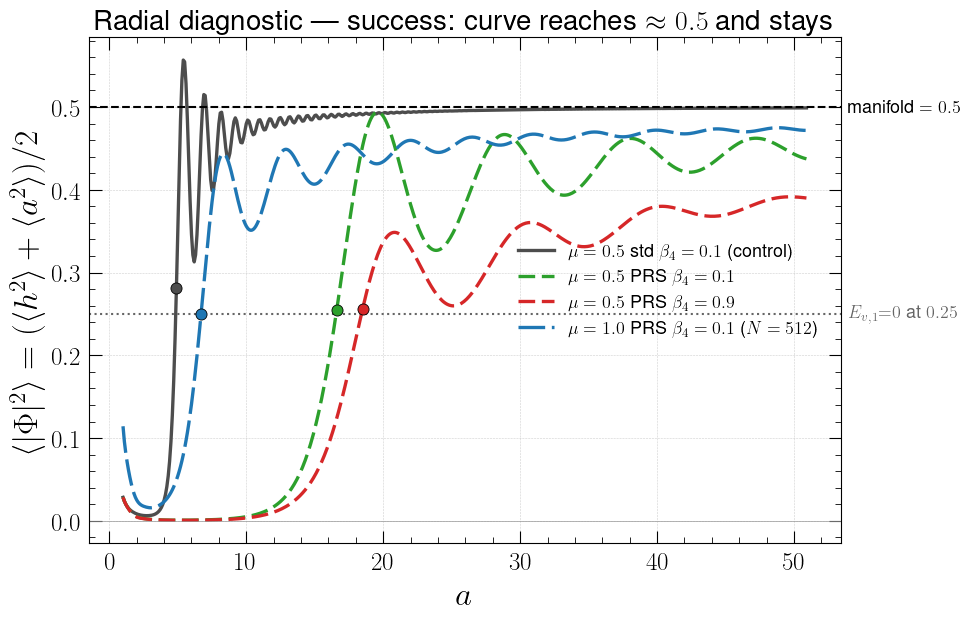

In [7]:
fig, ax = plt.subplots(figsize=(10, 6.5))
for d in ready:
    a_arr, phi2 = phi2_radial(d)
    ax.plot(a_arr, phi2, color=d['color'], ls=d['ls'], lw=d['lw'])
    mark_breaking(ax, d, a_arr, phi2)

ax.axhline(0.50, color='k',   ls='--', lw=1.5)
ax.axhline(0.25, color='0.4', ls=':',  lw=1.5)
ax.axhline(0.00, color='0.6', ls='-',  lw=0.5)
ax.text(1.01, 0.50, r'manifold $=0.5$',         transform=ax.get_yaxis_transform(),
        fontsize=13, va='center')
ax.text(1.01, 0.25, r'$E_{v,1}{=}0$ at $0.25$', transform=ax.get_yaxis_transform(),
        fontsize=13, va='center', color='0.4')
paper_ax(ax,
         ylabel=r'$\langle|\Phi|^2\rangle = (\langle h^2\rangle+\langle a^2\rangle)/2$',
         title=r'Radial diagnostic — success: curve reaches $\approx0.5$ and stays')
add_legend(ax, ready, loc='center right', bbox_to_anchor=(0.98, 0.5))
plt.tight_layout()
plt.savefig('Z4prs_mu1_phi2radial.pdf', bbox_inches='tight')
plt.show()

## 2. Potential energy terms (normalized)

All energies divided by $\mu^2/4$ (potential barrier height at $\phi=0$ above vacuum). This makes
different-$\mu$ runs directly comparable: $E_{v,1}/(\mu^2/4)=+1$ at origin, $-1$ at vacuum, $0$ at the
sign-flip.  
Left: mass term $E_{v,1}$ (the diagnostic). Right: quartic $E_{v,2}$ + Z4-breaking $E_{v,3}$ combined.

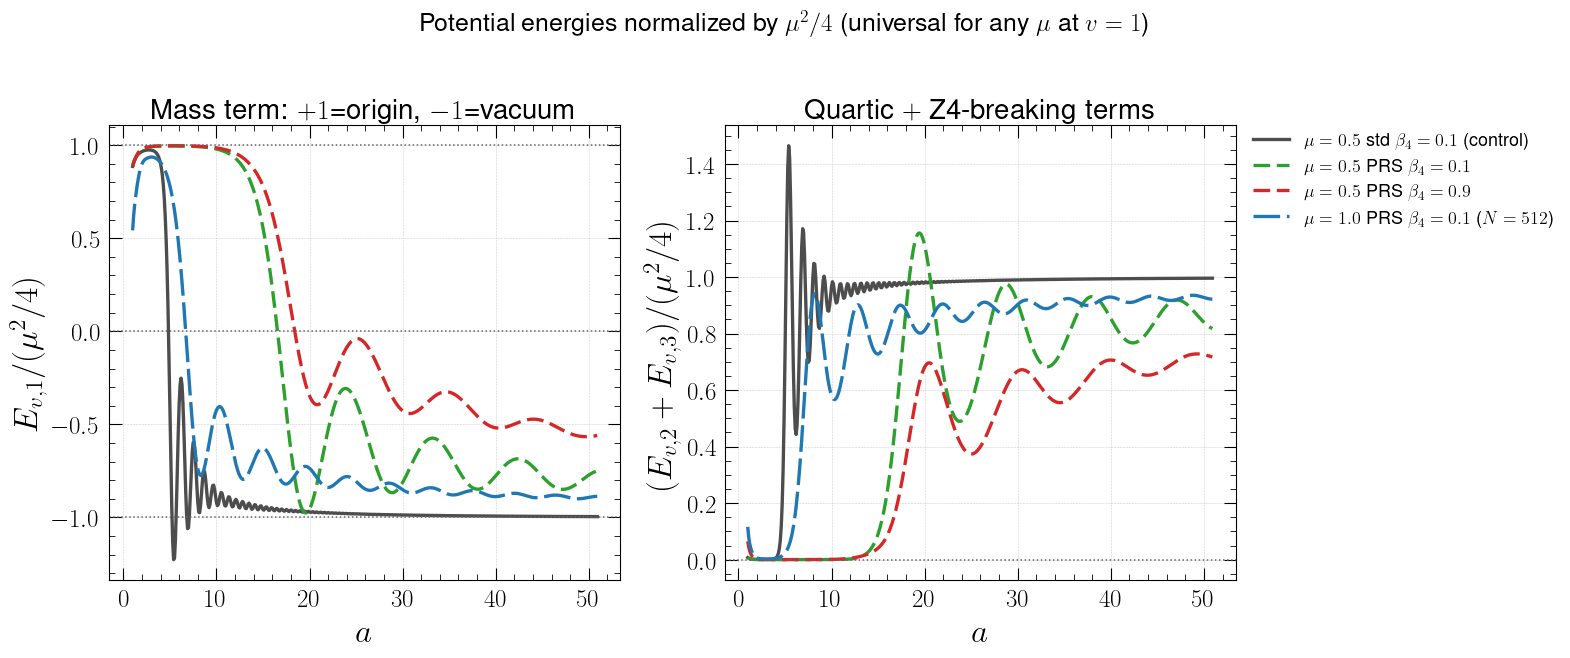

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    en   = d['energies']
    norm = d['mu']**2 / 4.0
    a_arr = get_a(d, en['eta'])
    axes[0].plot(a_arr, en['Ev_1']/norm,                    color=d['color'], ls=d['ls'], lw=d['lw'])
    axes[1].plot(a_arr, (en['Ev_2']+en['Ev_3'])/norm,       color=d['color'], ls=d['ls'], lw=d['lw'])

for val, lbl in [(-1, r'vacuum $=-1$'), (0, r'$0$'), (+1, r'origin $=+1$')]:
    axes[0].axhline(val, color='0.4', ls=':', lw=1.1)
axes[1].axhline(0, color='0.4', ls=':', lw=1.1)
paper_ax(axes[0], ylabel=r'$E_{v,1}/(\mu^2/4)$',
         title=r'Mass term: $+1$=origin, $-1$=vacuum')
paper_ax(axes[1], ylabel=r'$(E_{v,2}+E_{v,3})/(\mu^2/4)$',
         title=r'Quartic $+$ Z4-breaking terms')
add_legend(axes[1], ready)
fig.suptitle(r'Potential energies normalized by $\mu^2/4$ (universal for any $\mu$ at $v=1$)',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('Z4prs_mu1_Ev.pdf', bbox_inches='tight')
plt.show()

## 3. Kinetic and gradient energies

Both normalized by $\mu^2/4$. Gradient energy is a proxy for wall-network structure; kinetic
energy reflects field velocity. After scaling begins both should fall as $\sim 1/a^2$ (for
non-PRS) or stay flat in comoving units (for PRS, which freezes the wall width).

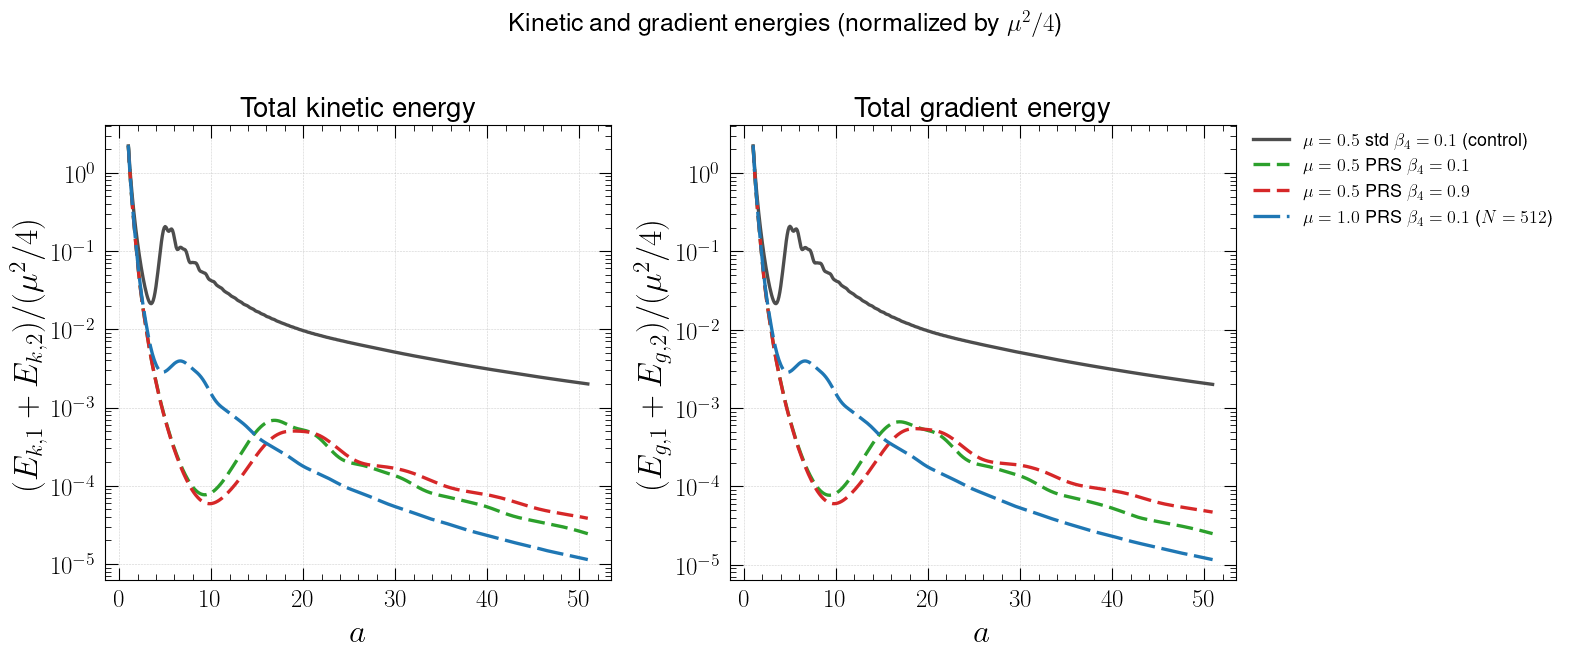

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    en   = d['energies']
    norm = d['mu']**2 / 4.0
    a_arr = get_a(d, en['eta'])
    axes[0].plot(a_arr, (en['Ek_1']+en['Ek_2'])/norm, color=d['color'], ls=d['ls'], lw=d['lw'])
    axes[1].plot(a_arr, (en['Eg_1']+en['Eg_2'])/norm, color=d['color'], ls=d['ls'], lw=d['lw'])

axes[0].set_yscale('log')
axes[1].set_yscale('log')
paper_ax(axes[0], ylabel=r'$(E_{k,1}+E_{k,2})/(\mu^2/4)$', title=r'Total kinetic energy')
paper_ax(axes[1], ylabel=r'$(E_{g,1}+E_{g,2})/(\mu^2/4)$', title=r'Total gradient energy')
add_legend(axes[1], ready)
fig.suptitle(r'Kinetic and gradient energies (normalized by $\mu^2/4$)', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('Z4prs_mu1_EkEg.pdf', bbox_inches='tight')
plt.show()

## 4. Total energy (relative)

PRS is **non-Lagrangian** — total energy is not conserved once PRS is active. The std run
should stay $\approx 1$; PRS runs will drift. The drift magnitude and sign tell us whether PRS
is adding or removing energy from the field.

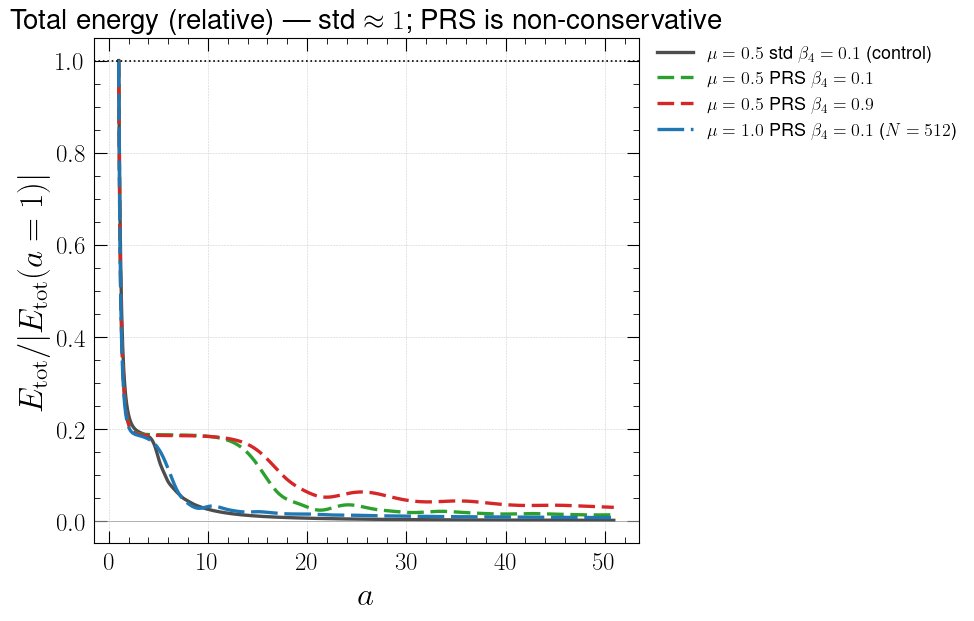

In [10]:
fig, ax = plt.subplots(figsize=(10, 6.5))
for d in ready:
    en    = d['energies']
    a_arr = get_a(d, en['eta'])
    E0    = en['E_tot'][0]
    if abs(E0) < 1e-30:
        continue
    ax.plot(a_arr, en['E_tot']/abs(E0), color=d['color'], ls=d['ls'], lw=d['lw'])

ax.axhline(1.0, color='k',   ls=':', lw=1.2)
ax.axhline(0.0, color='0.6', ls='-', lw=0.5)
paper_ax(ax, ylabel=r'$E_{\rm tot}/|E_{\rm tot}(a=1)|$',
         title=r'Total energy (relative) — std $\approx1$; PRS is non-conservative')
add_legend(ax, ready)
plt.tight_layout()
plt.savefig('Z4prs_mu1_Etot.pdf', bbox_inches='tight')
plt.show()

## 5. Wall-area parameters $\mathcal{A}_1$ and $\mathcal{A}_2$

$\mathcal{A}_k = \mathrm{Scal\_type\_}k / (2aH)$. Note: for fixed-background RD with $H_0=\mu$,
$H=1/a$ so $2aH=2$ = constant — the normalization is purely cosmetic here.
These are **phase-only** observables: $\theta=\arctan(a/h)$; they become noise
when $|\Phi|\to0$ (melt), so interpret only after $\langle|\Phi|^2\rangle$ confirms the field is
on the manifold. Dots ($\bullet$) = breaking onset.

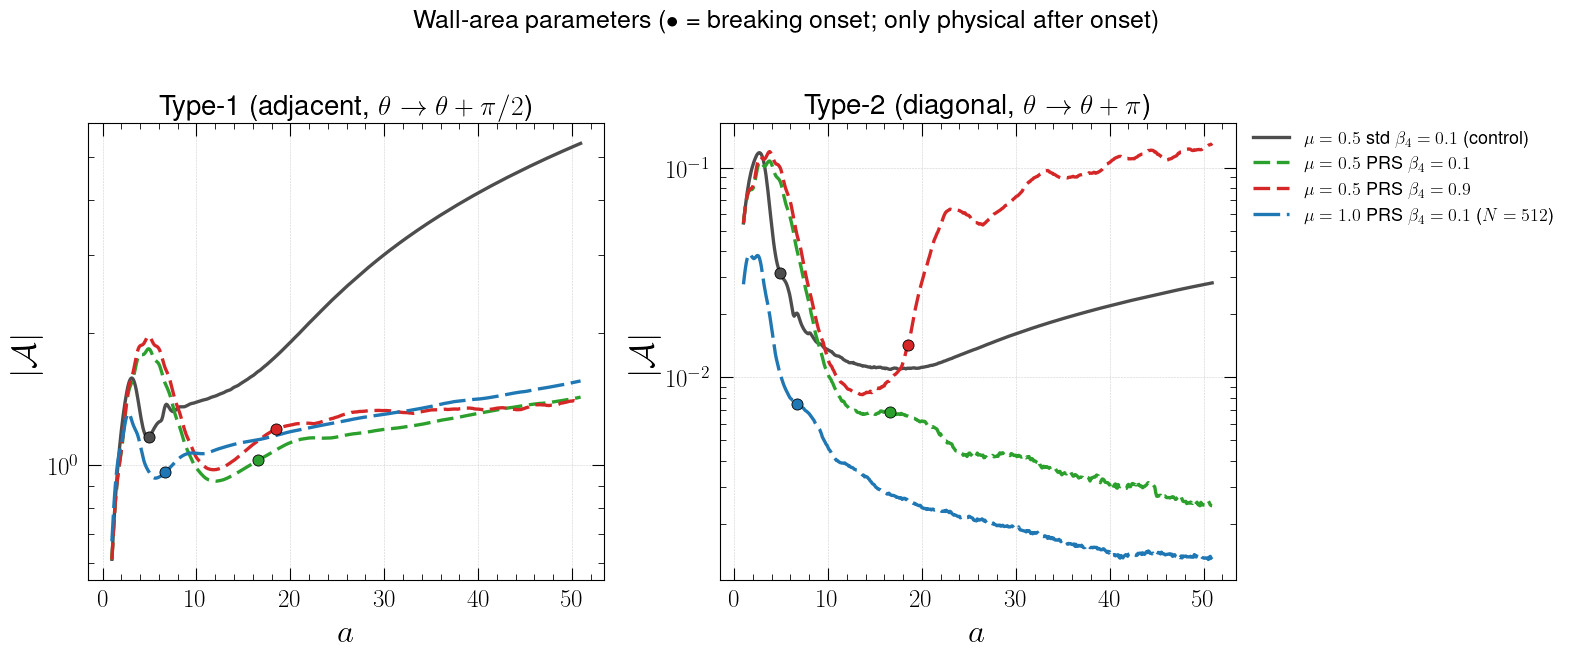

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    a1, A1 = area_param('scal1', d)
    a2, A2 = area_param('scal2', d)
    axes[0].plot(a1, np.abs(A1), color=d['color'], ls=d['ls'], lw=d['lw'])
    axes[1].plot(a2, np.abs(A2), color=d['color'], ls=d['ls'], lw=d['lw'])
    for ax, (aa, AA) in zip(axes, [(a1,A1),(a2,A2)]):
        mark_breaking(ax, d, aa, np.abs(AA))

for ax, ttl in zip(axes, [r'Type-1 (adjacent, $\theta\to\theta+\pi/2$)',
                           r'Type-2 (diagonal, $\theta\to\theta+\pi$)']):
    ax.set_yscale('log')
    paper_ax(ax, ylabel=r'$|\mathcal{A}|$', title=ttl)
add_legend(axes[1], ready)
fig.suptitle(r'Wall-area parameters ($\bullet$ = breaking onset; only physical after onset)',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('Z4prs_mu1_area.pdf', bbox_inches='tight')
plt.show()

## 6. Scalar-field means $\langle\phi\rangle \pm \sigma$

At a Z4 vacuum $h=\pm v=\pm1$, $a=0$ (or permutations). The mean wanders through zero before
breaking; after formation it reflects the domain distribution. The shaded band is $\pm\sigma$
where $\sigma^2=\langle\phi^2\rangle-\langle\phi\rangle^2$.

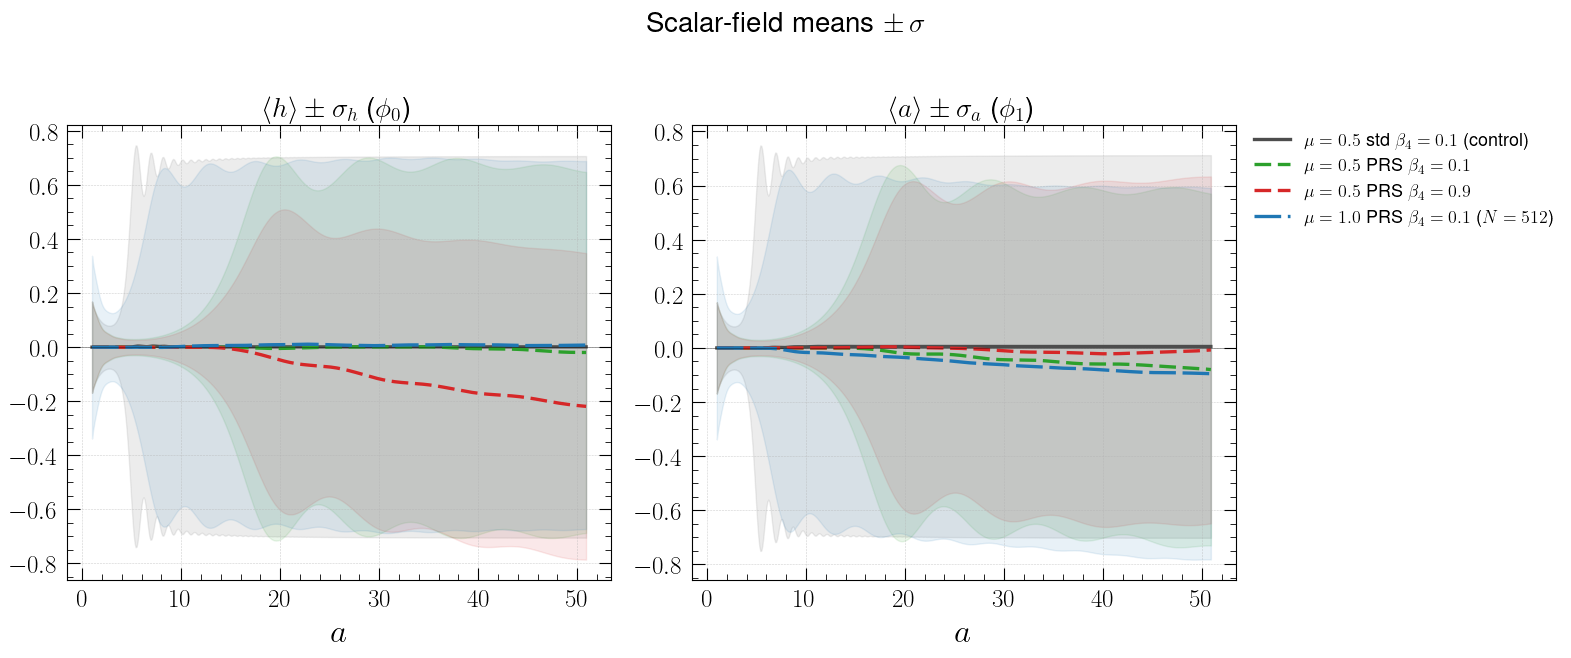

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    for ax, fkey in zip(axes, ('scalar_0', 'scalar_1')):
        sc = d.get(fkey)
        if sc is None:
            continue
        a_arr = get_a(d, sc['eta'])
        sigma = np.sqrt(np.maximum(sc['phi2'] - sc['phi']**2, 0.0))
        ax.fill_between(a_arr, sc['phi']-sigma, sc['phi']+sigma, alpha=0.10, color=d['color'])
        ax.plot(a_arr, sc['phi'], color=d['color'], ls=d['ls'], lw=d['lw'])

for ax, ttl in zip(axes, [r'$\langle h\rangle\pm\sigma_h$ ($\phi_0$)',
                           r'$\langle a\rangle\pm\sigma_a$ ($\phi_1$)']):
    ax.axhline(0, color='k', lw=0.6, alpha=0.4)
    paper_ax(ax, title=ttl)
add_legend(axes[1], ready)
fig.suptitle(r'Scalar-field means $\pm\,\sigma$', fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('Z4prs_mu1_field_mean.pdf', bbox_inches='tight')
plt.show()

## 7. Scalar-field rms — order parameters

$\sqrt{\langle h^2\rangle}$ and $\sqrt{\langle a^2\rangle}$ should plateau at $v/\sqrt{2}\approx0.707$
after symmetry breaking (the two components share the vacuum energy equally on average in a
disordered network).  
The std run will hold this plateau while the std walls are resolved; the PRS run should hold it
indefinitely — that is the central claim of the fix.

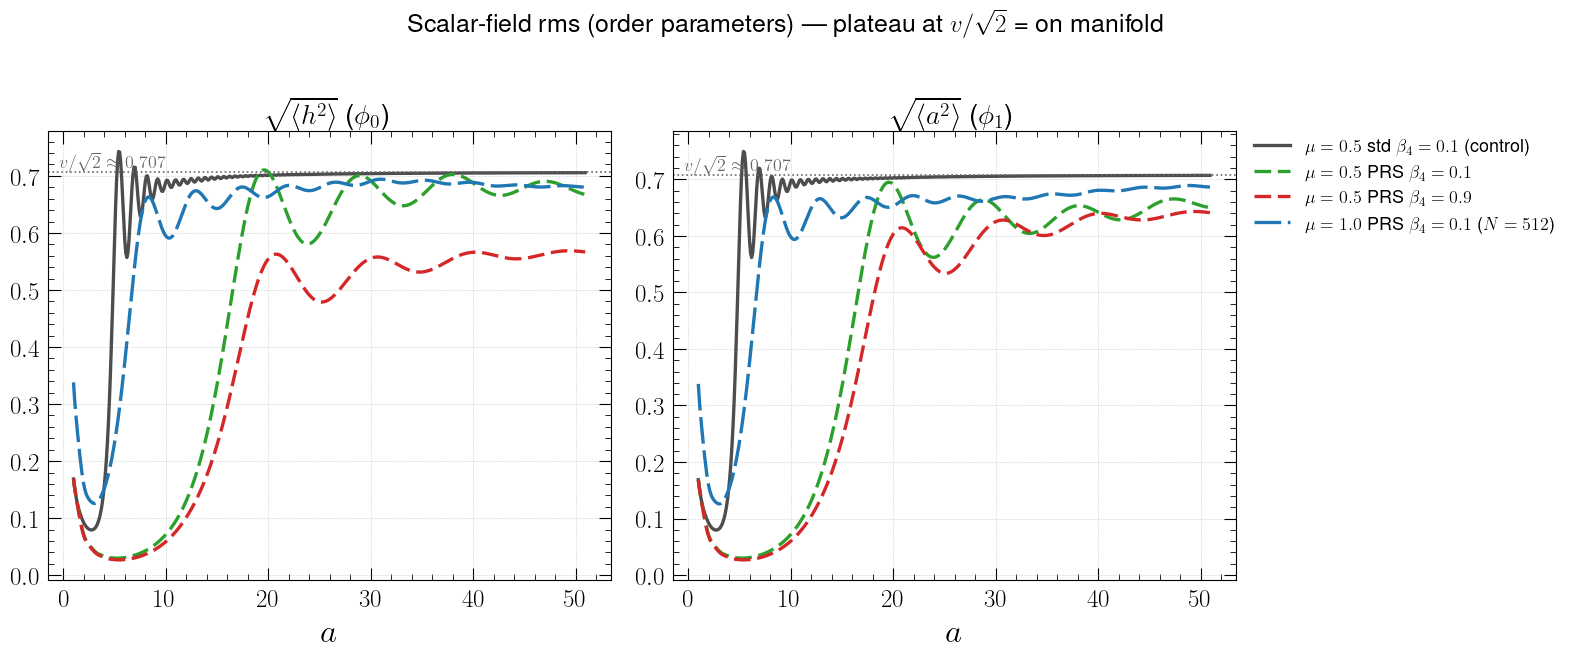

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    for ax, fkey in zip(axes, ('scalar_0', 'scalar_1')):
        sc = d.get(fkey)
        if sc is None:
            continue
        a_arr = get_a(d, sc['eta'])
        ax.plot(a_arr, sc['rms_phi'], color=d['color'], ls=d['ls'], lw=d['lw'])

vac = 1.0 / np.sqrt(2.0)
for ax, ttl in zip(axes, [r'$\sqrt{\langle h^2\rangle}$ ($\phi_0$)',
                           r'$\sqrt{\langle a^2\rangle}$ ($\phi_1$)']):
    ax.axhline(vac, color='0.4', ls=':', lw=1.2)
    ax.text(0.02, vac, r'$v/\sqrt{2}\approx0.707$', color='0.4', fontsize=13,
            va='bottom', ha='left', transform=ax.get_yaxis_transform())
    paper_ax(ax, title=ttl)
add_legend(axes[1], ready)
fig.suptitle(r'Scalar-field rms (order parameters) — plateau at $v/\sqrt{2}$ = on manifold',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('Z4prs_mu1_field_rms.pdf', bbox_inches='tight')
plt.show()

## 8. Scale factor and Hubble rate

Consistency check: all runs use fixed-background RD with $H_0=\mu$, giving $a=1+\eta$ and
$H=1/a$ exactly. Deviations from the theoretical curves would indicate a code or input-file
problem.

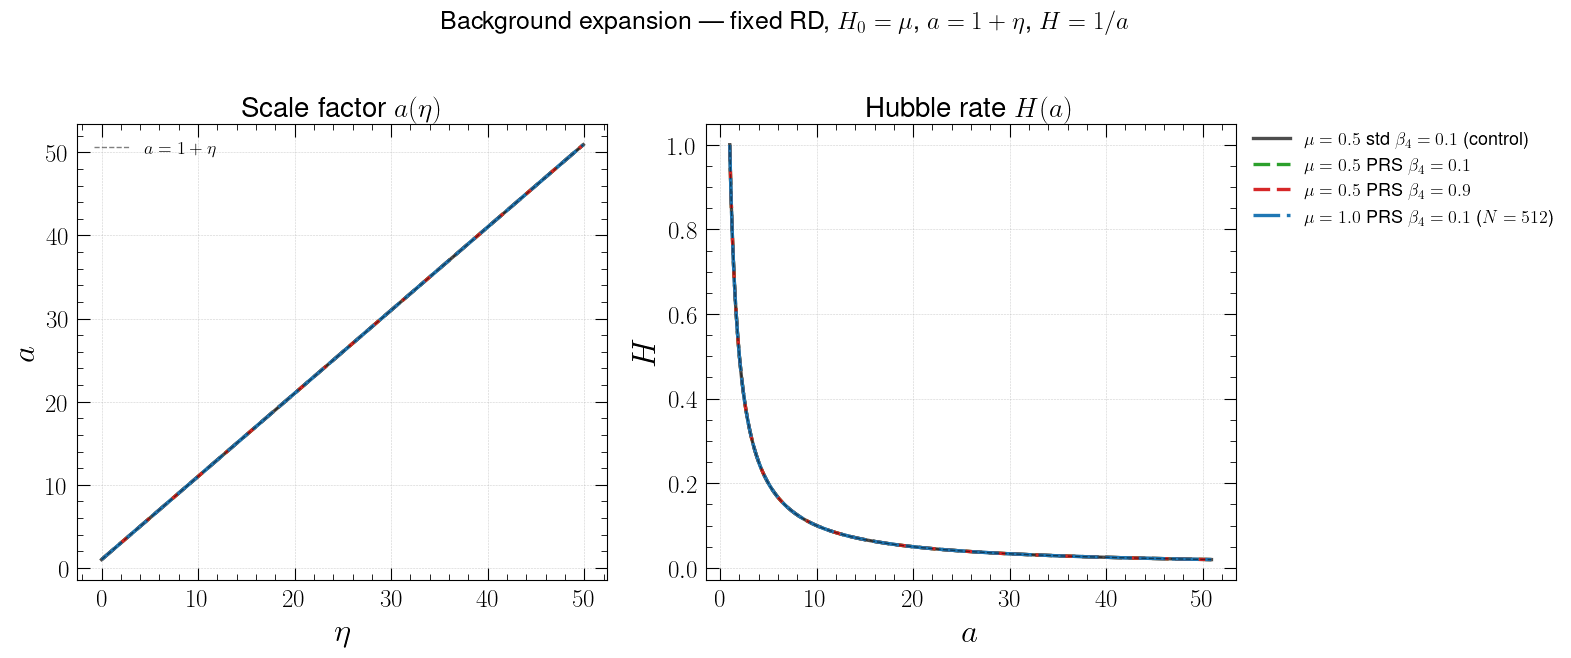

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for d in ready:
    sf = d['scale_factor']
    axes[0].plot(sf['eta'], sf['a'], color=d['color'], ls=d['ls'], lw=d['lw'])
    axes[1].plot(sf['a'],   sf['H'], color=d['color'], ls=d['ls'], lw=d['lw'])

if ready:
    eta_max = ready[0]['scale_factor']['eta'][-1]
    eta_th  = np.linspace(0, eta_max, 300)
    a_th    = 1.0 + eta_th
    axes[0].plot(eta_th, a_th,     'k--', lw=1.0, alpha=0.5, label=r'$a=1+\eta$')
    axes[1].plot(a_th,  1.0/a_th, 'k--', lw=1.0, alpha=0.5, label=r'$H=1/a$')

paper_ax(axes[0], xlabel=r'$\eta$', ylabel=r'$a$', title=r'Scale factor $a(\eta)$')
paper_ax(axes[1], ylabel=r'$H$', title=r'Hubble rate $H(a)$')
axes[0].legend(fontsize=13, frameon=False)
axes[1].legend(fontsize=13, frameon=False)
add_legend(axes[1], ready)
fig.suptitle(r'Background expansion — fixed RD, $H_0=\mu$, $a=1+\eta$, $H=1/a$',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('Z4prs_mu1_scalefactor.pdf', bbox_inches='tight')
plt.show()

## 9. Summary table

In [15]:
print(f"{'card':22s} {'mu':>5s} {'N':>4s} {'b4':>4s} {'PRS':>4s}"
      f" {'break@a':>8s} {'peak rms_h':>11s} {'peak<|Ph|^2>':>13s} {'last a':>7s}")
print('-' * 83)
for d in ready:
    a_b  = breaking_onset_a(d)
    s0   = d.get('scalar_0')
    s1   = d.get('scalar_1')
    peak_rms  = np.sqrt(np.maximum(s0['phi2'], 0.0)).max() if s0 is not None else float('nan')
    phi2_peak = ((s0['phi2']+s1['phi2'])/2.0).max() if (s0 is not None and s1 is not None) else float('nan')
    last_a    = d['scale_factor']['a'][-1]
    print(f"{d['name']:22s} {d['mu']:>5.2f} {d['N']:>4d} {d['beta4']:>4.1f}"
          f" {'yes' if d['prs'] else 'no':>4s}"
          f" {(str(round(a_b,2)) if a_b is not None else 'none'):>8s}"
          f" {peak_rms:>11.3f} {phi2_peak:>13.3f} {last_a:>7.1f}")

card                      mu    N   b4  PRS  break@a  peak rms_h  peak<|Ph|^2>  last a
-----------------------------------------------------------------------------------
mu0p5_std               0.50  256  0.1   no      4.9       0.743         0.557    50.9
mu0p5_prs               0.50  256  0.1  yes     16.6       0.710         0.494    50.9
mu0p5_b40p9_prs         0.50  256  0.9  yes     18.5       0.608         0.391    50.9
mu1_N512_prs            1.00  512  0.1  yes      6.7       0.694         0.475    50.9
